## Chapter 13 of *R for Data Science* (2e, 2023)

In [1]:
%load_ext autoreload
%autoreload 2

from hea import data, col, n

In [2]:
from hea import n
flights = data("flights")
flights

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
2013,9,30,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
2013,9,30,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


### 13.2

In [3]:
from hea.R import parse_double, parse_number

parse_double(["1.2", "5.6", "1e3"]), parse_number(["$1,234", "USD 3,513", "59%"])

([1.2, 5.6, 1000.0], [1234.0, 3513.0, 59.0])

### 13.3

In [4]:
flights.count("dest")

dest,n
str,u32
"""IAH""",7198
"""MIA""",11728
"""BQN""",896
"""ATL""",17215
"""ORD""",17283
…,…
"""LEX""",1
"""CHO""",52
"""TVC""",101


In [5]:
flights.count("dest", sort=True)

dest,n
str,u32
"""ORD""",17283
"""ATL""",17215
"""LAX""",16174
"""BOS""",15508
"""MCO""",14082
…,…
"""MTJ""",15
"""SBN""",10
"""ANC""",8


In [14]:
(
    flights
        .group_by("dest")
        .summarize(
            n=n(),
            delay=col("arr_delay").mean()
        )
)

dest,n,delay
str,u32,f64
"""IAH""",7198,4.24079
"""MIA""",11728,0.29906
"""BQN""",896,8.245495
"""ATL""",17215,11.300113
"""ORD""",17283,5.876615
…,…,…
"""LEX""",1,-22.0
"""CHO""",52,9.5
"""TVC""",101,12.968421


In [10]:
from hea import n_distinct, desc
(
    flights
        .group_by("dest")
        .summarize(carriers=n_distinct("carrier"))
        .arrange(desc("carriers"))
)

dest,carriers
str,u32
"""ATL""",7
"""ORD""",7
"""TPA""",7
"""BOS""",7
"""CLT""",7
…,…
"""SBN""",1
"""LEX""",1
"""CHO""",1


In [13]:
(
    flights
        .group_by("tailnum")
        .summarize(miles=col("distance").sum())
)

tailnum,miles
str,i64
"""N14228""",171713
"""N24211""",172934
"""N619AA""",32141
"""N804JB""",311992
"""N668DN""",50352
…,…
"""N766SK""",419
"""N772SK""",419
"""N776SK""",419


In [20]:
(
    flights
        .group_by("dest")
        .summarize(n_cancelled=col("dep_time").is_null().sum())
        .sort("dest")
)

dest,n_cancelled
str,u32
"""ABQ""",0
"""ACK""",0
"""ALB""",20
"""ANC""",0
"""ATL""",317
…,…
"""TPA""",59
"""TUL""",16
"""TVC""",5


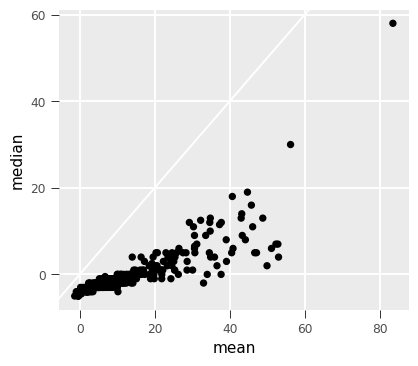

In [9]:


(
    flights
        .group_by("year", "month", "day")
        .summarize(
            mean=col("dep_delay").mean(),
            median=col("dep_delay").median(),
            n=n(),
            _groups="drop"
        ).ggplot(
            x="mean", y="median",
        ).geom_abline(
            slope=1, intercept=0, color="white", linewidth=2
        ).geom_point()
        
)